In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

print("Week 2 - Data Exploration and Preprocessing")
print("CampusIQ Academic Policy RAG")

Week 2 - Data Exploration and Preprocessing
CampusIQ Academic Policy RAG


In [11]:
from pypdf import PdfReader
from pathlib import Path

pdf_path = Path("../data/raw/R22B.Tech.AcademicRegulations.pdf")

reader = PdfReader(str(pdf_path))

pages = []

for page in reader.pages:
    text = page.extract_text() or ""
    pages.append(text)

full_text = "\n".join(pages)

print("PDF exists:", pdf_path.exists())
print("Number of pages:", len(reader.pages))
print("Total characters:", len(full_text))

PDF exists: True
Number of pages: 24
Total characters: 54062


In [12]:
import re

def clean_text(text):
    """Clean extracted policy text."""
    text = text.replace("\n", " ")
    text = re.sub(r"\s+", " ", text)
    return text.strip()


def chunk_text(text, chunk_size=1000, overlap=150):
    """Split policy text into overlapping chunks."""
    chunks = []
    start = 0

    while start < len(text):
        end = start + chunk_size
        chunk = text[start:end].strip()

        if chunk:
            chunks.append(chunk)

        if end >= len(text):
            break

        start = end - overlap

    return chunks


cleaned_text = clean_text(full_text)
chunks = chunk_text(cleaned_text)

df = pd.DataFrame({
    "chunk_id": range(len(chunks)),
    "text": chunks
})

print("Total chunks:", len(df))
print("\nFirst 3 chunks:")
display(df.head(3))

Total chunks: 62

First 3 chunks:


,chunk_id,text
0,0,1 JAWAHARLAL NEHRU TECHNOLOGICAL UNIVERSITY HY...
1,1,r on the basis of any other order of merit app...
2,2,arious terms and abbreviations used in these a...


In [13]:
# Basic dataset information

print("Dataset shape:", df.shape)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nEmpty text chunks:", (df["text"].str.strip() == "").sum())

Dataset shape: (62, 2)

Missing values:
chunk_id    0
text        0
dtype: int64

Duplicate rows: 0

Empty text chunks: 0


In [14]:
# Basic text statistics

df["character_count"] = df["text"].str.len()
df["word_count"] = df["text"].str.split().str.len()

print("Character count statistics:")
print(df["character_count"].describe())

print("\nWord count statistics:")
print(df["word_count"].describe())

Character count statistics:
count      62.000000
mean      995.661290
std        31.456941
min       752.000000
25%       999.000000
50%      1000.000000
75%      1000.000000
max      1000.000000
Name: character_count, dtype: float64

Word count statistics:
count     62.000000
mean     166.774194
std       16.866320
min      125.000000
25%      159.000000
50%      164.500000
75%      173.750000
max      239.000000
Name: word_count, dtype: float64


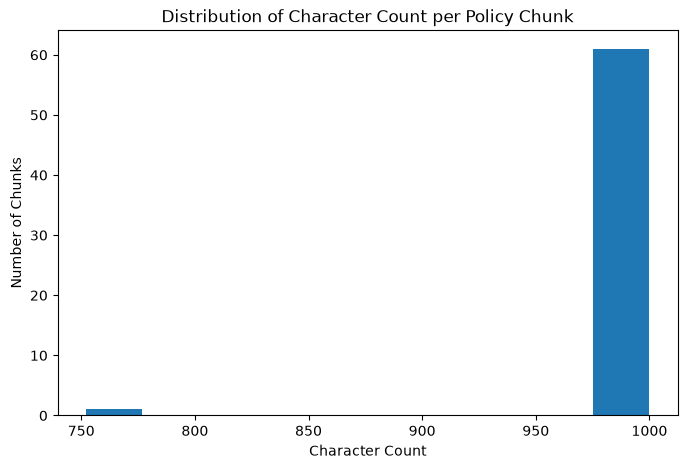

In [15]:
plt.figure(figsize=(8, 5))

plt.hist(df["character_count"], bins=10)

plt.title("Distribution of Character Count per Policy Chunk")
plt.xlabel("Character Count")
plt.ylabel("Number of Chunks")

plt.show()

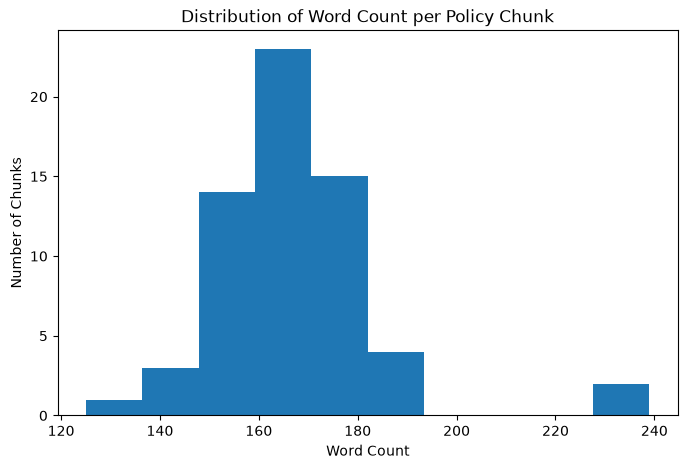

In [16]:
plt.figure(figsize=(8, 5))

plt.hist(df["word_count"], bins=10)

plt.title("Distribution of Word Count per Policy Chunk")
plt.xlabel("Word Count")
plt.ylabel("Number of Chunks")

plt.show()

In [17]:
print("Shortest chunk:")
display(df.loc[df["character_count"].idxmin(), ["chunk_id", "character_count", "word_count"]])

print("\nLongest chunk:")
display(df.loc[df["character_count"].idxmax(), ["chunk_id", "character_count", "word_count"]])

Shortest chunk:


chunk_id            61
character_count    752
word_count         125
Name: 61, dtype: int64


Longest chunk:


chunk_id              1
character_count    1000
word_count          156
Name: 1, dtype: int64

In [18]:
# Feature Engineering

df["sentence_count"] = (
    df["text"]
    .str.count(r"[.!?]")
)

df["uppercase_count"] = (
    df["text"]
    .str.count(r"[A-Z]")
)

policy_keywords = [
    "attendance",
    "examination",
    "exam",
    "marks",
    "grade",
    "credits",
    "semester",
    "fees",
    "fee",
    "promotion",
    "eligibility",
    "academic",
    "course",
    "regulation"
]

for keyword in policy_keywords:
    df[f"{keyword}_count"] = (
        df["text"]
        .str.lower()
        .str.count(keyword)
    )

print("Feature engineering completed.")
print("\nDataset shape:", df.shape)

display(df.head())

Feature engineering completed.

Dataset shape: (62, 20)


,chunk_id,text,character_count,word_count,sentence_count,uppercase_count,attendance_count,examination_count,exam_count,marks_count,grade_count,credits_count,semester_count,fees_count,fee_count,promotion_count,eligibility_count,academic_count,course_count,regulation_count
0,0,1 JAWAHARLAL NEHRU TECHNOLOGICAL UNIVERSITY HY...,999,146,11,176,0,0,0,0,0,0,1,0,0,0,1,3,0,1
1,1,r on the basis of any other order of merit app...,1000,156,18,32,0,0,0,0,0,1,4,0,0,0,0,3,1,1
2,2,arious terms and abbreviations used in these a...,1000,160,8,55,0,0,0,0,0,2,9,0,0,0,0,3,5,1
3,3,r one hour/ week/ semester for Theory/ Lecture...,1000,143,12,87,0,0,0,0,0,1,2,0,0,0,0,0,12,0
4,4,Social Sciences Includes subjects related to H...,999,142,6,81,0,0,0,0,0,0,0,0,0,0,0,0,6,0


In [19]:
# Check missing values after feature engineering

missing_values = df.isnull().sum()

print("Missing values by column:")
display(missing_values[missing_values > 0])

print("\nTotal missing values:", df.isnull().sum().sum())

Missing values by column:


Series([], dtype: int64)


Total missing values: 0


In [20]:
# Total occurrences of important academic-policy keywords

keyword_columns = [
    f"{keyword}_count"
    for keyword in policy_keywords
]

keyword_totals = df[keyword_columns].sum().sort_values(
    ascending=False
)

print("Keyword frequency across all policy chunks:")
display(keyword_totals)

Keyword frequency across all policy chunks:


semester_count       212
course_count         158
exam_count           151
examination_count    132
marks_count          106
credits_count         62
academic_count        52
grade_count           48
regulation_count      44
attendance_count      23
promotion_count        5
fee_count              2
eligibility_count      2
fees_count             1
dtype: int64

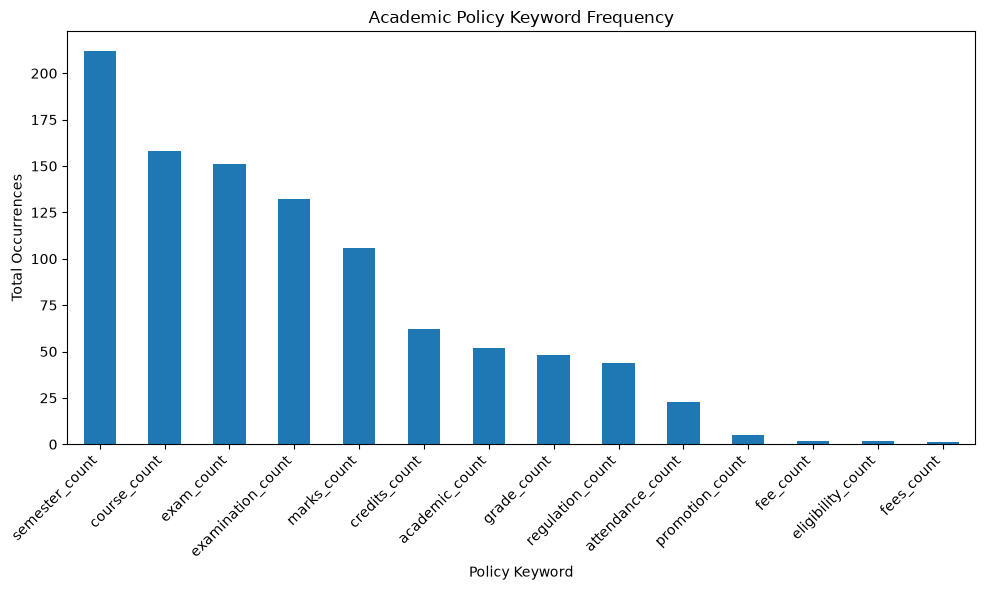

In [21]:
plt.figure(figsize=(10, 6))

keyword_totals.plot(kind="bar")

plt.title("Academic Policy Keyword Frequency")
plt.xlabel("Policy Keyword")
plt.ylabel("Total Occurrences")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [23]:
# Final preprocessing

processed_df = df.copy()

# Remove duplicate rows
processed_df = processed_df.drop_duplicates()

# Remove rows with empty text
processed_df = processed_df[
    processed_df["text"].str.strip() != ""
]

# Reset index
processed_df = processed_df.reset_index(drop=True)

print("Original rows:", len(df))
print("Processed rows:", len(processed_df))
print("Rows removed:", len(df) - len(processed_df))


Original rows: 62
Processed rows: 62
Rows removed: 0


In [24]:
# Save processed dataset

output_path = Path("../data/processed/jntuh_policy_chunks.csv")

processed_df.to_csv(
    output_path,
    index=False
)

print("Processed dataset saved to:")
print(output_path)

OSError: Cannot save file into a non-existent directory: '../data/processed'

In [25]:
from pathlib import Path

output_dir = Path("../data/processed")
output_dir.mkdir(parents=True, exist_ok=True)

output_path = output_dir / "jntuh_policy_chunks.csv"

processed_df.to_csv(
    output_path,
    index=False
)

print("Processed dataset saved successfully!")
print(output_path)

Processed dataset saved successfully!
../data/processed/jntuh_policy_chunks.csv


In [26]:
from pathlib import Path
import pandas as pd

output_path = Path("../data/processed/jntuh_policy_chunks.csv")

print("File exists:", output_path.exists())

processed_check = pd.read_csv(output_path)

print("Dataset shape:", processed_check.shape)
display(processed_check.head())

File exists: True
Dataset shape: (62, 20)


,chunk_id,text,character_count,word_count,sentence_count,uppercase_count,attendance_count,examination_count,exam_count,marks_count,grade_count,credits_count,semester_count,fees_count,fee_count,promotion_count,eligibility_count,academic_count,course_count,regulation_count
0,0,1 JAWAHARLAL NEHRU TECHNOLOGICAL UNIVERSITY HY...,999,146,11,176,0,0,0,0,0,0,1,0,0,0,1,3,0,1
1,1,r on the basis of any other order of merit app...,1000,156,18,32,0,0,0,0,0,1,4,0,0,0,0,3,1,1
2,2,arious terms and abbreviations used in these a...,1000,160,8,55,0,0,0,0,0,2,9,0,0,0,0,3,5,1
3,3,r one hour/ week/ semester for Theory/ Lecture...,1000,143,12,87,0,0,0,0,0,1,2,0,0,0,0,0,12,0
4,4,Social Sciences Includes subjects related to H...,999,142,6,81,0,0,0,0,0,0,0,0,0,0,0,0,6,0
